# Statistical Sensor 
## AnalyserWeek 3: Project 2 - Statistical Anomaly Detection 
## Overview
This project focuses on identifying "outliers" in a motor's temperature data over a 7-day period. By calculating how many standard deviations a reading is from the average (the Z-Score), we can mathematically distinguish between normal operation and serious system faults.Key Features7-Day Simulation: Generates 168 hours of simulated motor temperature data.Statistical Metrics: Computes Mean, Variance, Standard Deviation, and Percentiles using NumPy.Z-Score Detection: Flags any reading with an absolute Z-score ($|z| > 2.5$) as a statistical anomaly.Gaussian Visualization: Plots a histogram of the data overlaid with a Normal Distribution curve to visualize the data spread.Math ImplementationThe core of this project is the Z-Score formula, which measures the distance from the mean in terms of standard deviations:$$z = \frac{x - \mu}{\sigma}$$$\mu$ (Mean): The average temperature.$\sigma$ (Std Dev): The amount of variation or "swing" in the data.Classification: If $|z| > 2.5$, the reading is highlighted in red as an anomaly.

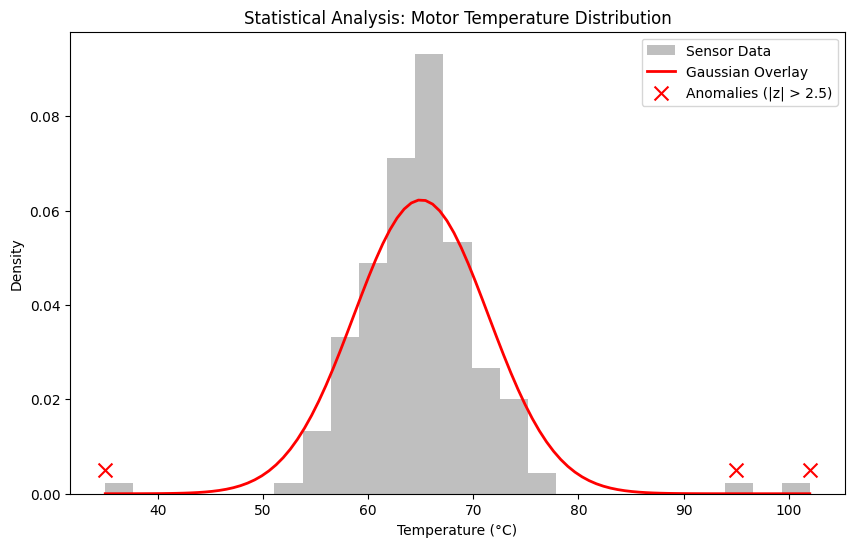

Mean: 65.04°C
Standard Deviation: 6.40
Anomalies Detected: 3


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. DATA: Simulate 7 days of motor temperature (168 hours)
np.random.seed(42)
# Average motor temp is 65°C with a standard deviation of 5°C
data = np.random.normal(65, 5, 168) 
# Add manual anomalies (extreme spikes and drops)
data[10], data[80], data[150] = 95, 35, 102 

# 2. STATISTICS: Compute required metrics
mean_val = np.mean(data)
variance_val = np.var(data)
std_dev = np.std(data)
percentiles = np.percentile(data, [25, 50, 75]) # 25th, Median, 75th

# 3. ANOMALIES: Calculate Z-Scores
# Formula: z = (x - mean) / std_dev
z_scores = (data - mean_val) / std_dev
# Flag readings where the absolute z-score is greater than 2.5
anomalies = data[np.abs(z_scores) > 2.5]
anomaly_indices = np.where(np.abs(z_scores) > 2.5)[0]

# 4. PLOT: Distribution & Gaussian Overlay
plt.figure(figsize=(10, 6))

# Histogram of real readings
count, bins, _ = plt.hist(data, bins=25, density=True, alpha=0.5, color='gray', label='Sensor Data')

# Gaussian (Normal) Curve overlay
x = np.linspace(min(data), max(data), 100)
plt.plot(x, norm.pdf(x, mean_val, std_dev), 'r-', lw=2, label='Gaussian Overlay')

# Highlight Anomalies in Red
plt.scatter(anomalies, [0.005]*len(anomalies), color='red', marker='x', s=100, label='Anomalies (|z| > 2.5)')

plt.title("Statistical Analysis: Motor Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Density")
plt.legend()
plt.show()

# Output the findings
print(f"Mean: {mean_val:.2f}°C")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Anomalies Detected: {len(anomalies)}")